# Notebook 03 — Tier-0 Mechanism Sanity Scan

## Goal

This notebook performs a first Tier-0 sanity scan for mechanism-to-observable mapping in the `pybamm-aging-bridge` project.

The purpose is not to build the full perturbation matrix, but to verify that selected DFN-level physical perturbations are numerically runnable and produce interpretable ECM-level observable changes.

## Scientific context

The project investigates how electrochemical degradation-related perturbations manifest as engineering-level diagnostic fingerprints.

The core mapping is:

DFN-level physical perturbation  
→ simulated HPPC response  
→ CDEFG / Ri / relaxation extraction  
→ ECM-level observable fingerprint

This notebook starts with isolated strong perturbations to test directionality and numerical stability before running the full Phase B scan.

## Tier-0 perturbations

The initial sanity scan will test:

1. Baseline Chen2020
2. Reduced solid diffusion coefficient
3. Reduced exchange-current density
4. Increased contact resistance

LLI-equivalent stoichiometry shift and LAM-equivalent active material loss are deferred until the first three perturbation families are confirmed runnable.

## Workflow

1. Import packages and audit paths.
2. Define shared HPPC extraction functions.
3. Run baseline HPPC at SOC=50%.
4. Run Tier-0 perturbation cases.
5. Extract CDEFG points, Ri_CD, Ri_EF, tau1/tau2 descriptors.
6. Compare observable fingerprints against baseline.
7. Generate visual audit plots for voltage relaxation and diagnostic summary.

## Expected outputs

- Tier-0 result table
- HPPC voltage/current plots
- CDEFG audit plots
- relaxation fit summaries
- mechanism-to-observable comparison table

## Interpretation boundary

This notebook is a sanity scan only.

A result in this notebook does not establish a general aging model. It only checks whether a physical perturbation can be mapped into observable HPPC fingerprints under a controlled one-SOC baseline condition.

Negative results must be stated as:

“not observed under this Tier-0 perturbation condition,”

not as a general mechanistic exclusion.

In [1]:
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pybamm

from scipy.optimize import curve_fit

print("PyBaMM version:", pybamm.__version__)

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"
FIGURES = ROOT / "figures"

DATA.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)

print("ROOT:", ROOT)
print("DATA:", DATA)
print("FIGURES:", FIGURES)

PyBaMM version: 26.3.1
ROOT: /Users/louislu/projects/pybamm-aging-bridge
DATA: /Users/louislu/projects/pybamm-aging-bridge/data
FIGURES: /Users/louislu/projects/pybamm-aging-bridge/figures


In [2]:
SOC_INIT = 0.50
PULSE_C_RATE = "1C"
PULSE_DURATION_S = 10
REST_BEFORE_S = 60
RELAXATION_S = 600
OUTPUT_PERIOD = "0.1 seconds"

print("Shared HPPC configuration")
print("SOC_INIT:", SOC_INIT)
print("Pulse:", PULSE_C_RATE, "for", PULSE_DURATION_S, "s")
print("Rest before pulse:", REST_BEFORE_S, "s")
print("Relaxation:", RELAXATION_S, "s")
print("Output period:", OUTPUT_PERIOD)

Shared HPPC configuration
SOC_INIT: 0.5
Pulse: 1C for 10 s
Rest before pulse: 60 s
Relaxation: 600 s
Output period: 0.1 seconds


In [3]:
def run_hppc_case(case_name, parameter_values, soc_init=SOC_INIT):
    """
    Run one SOC=50% HPPC-style pulse:
    rest -> 1C discharge pulse -> relaxation.

    PyBaMM convention:
    +I = discharge
    -I = charge
    """
    model = pybamm.lithium_ion.DFN()

    experiment = pybamm.Experiment(
        [
            f"Rest for {REST_BEFORE_S} seconds",
            f"Discharge at {PULSE_C_RATE} for {PULSE_DURATION_S} seconds",
            f"Rest for {RELAXATION_S} seconds",
        ],
        period=OUTPUT_PERIOD,
    )

    sim = pybamm.Simulation(
        model,
        parameter_values=parameter_values,
        experiment=experiment,
    )

    sim.set_initial_soc(soc_init, direction="discharge")
    solution = sim.solve()

    df = pd.DataFrame(
        {
            "case": case_name,
            "time_s": solution["Time [s]"].entries,
            "voltage_V": solution["Terminal voltage [V]"].entries,
            "current_A_pybamm": solution["Current [A]"].entries,
        }
    )
    df["time_rel_s"] = df["time_s"] - df["time_s"].iloc[0]
    df["current_A_exp"] = -df["current_A_pybamm"]

    return df, solution

In [4]:
def extract_cdefg_and_ri(df, current_threshold_A=0.1):
    """
    Extract CDEFG-style HPPC points and fixed-window Ri values.
    Uses PyBaMM current convention for pulse detection.
    """
    t = df["time_rel_s"].values
    u = df["voltage_V"].values
    i = df["current_A_pybamm"].values

    current_abs = np.abs(i)
    pulse_mask = current_abs > current_threshold_A
    pulse_indices = np.where(pulse_mask)[0]

    if len(pulse_indices) == 0:
        raise ValueError("No pulse detected.")

    pulse_start_idx = pulse_indices[0]
    pulse_end_idx = pulse_indices[-1]

    t_start = float(t[pulse_start_idx])
    t_end = float(t[pulse_end_idx])

    C_window = (t >= t_start - 1.0) & (t < t_start)
    D_window = (t >= t_start + 0.1) & (t <= t_start + 0.3)
    E_window = (t >= t_end - 0.3) & (t <= t_end)
    F_window = (t > t_end) & (t <= t_end + 0.3)
    G_window = (t >= t_end + RELAXATION_S - 10) & (t <= t_end + RELAXATION_S)

    windows = {
        "C": C_window,
        "D": D_window,
        "E": E_window,
        "F": F_window,
        "G": G_window,
    }

    points = {}
    for label, mask in windows.items():
        if mask.sum() == 0:
            raise ValueError(f"{label} window has no data points.")
        points[label] = {
            "t_s": float(np.median(t[mask])),
            "U_V": float(np.median(u[mask])),
            "n_points": int(mask.sum()),
        }

    # Pulse current magnitude from D window and pre-window
    I_C = float(np.median(i[C_window]))
    I_D = float(np.median(i[D_window]))
    I_E = float(np.median(i[E_window]))
    I_F = float(np.median(i[F_window]))

    dI_CD = I_D - I_C
    dI_EF = I_F - I_E

    Ri_CD_mohm = abs((points["D"]["U_V"] - points["C"]["U_V"]) / dI_CD) * 1000
    Ri_EF_mohm = abs((points["F"]["U_V"] - points["E"]["U_V"]) / dI_EF) * 1000

    result = {
        "pulse_start_s": t_start,
        "pulse_end_s": t_end,
        "pulse_duration_s": t_end - t_start,
        "Ri_CD_mohm": Ri_CD_mohm,
        "Ri_EF_mohm": Ri_EF_mohm,
        "C_U_V": points["C"]["U_V"],
        "D_U_V": points["D"]["U_V"],
        "E_U_V": points["E"]["U_V"],
        "F_U_V": points["F"]["U_V"],
        "G_U_V": points["G"]["U_V"],
    }

    return result, points

In [5]:
def fit_biexp_with_window(relax, fit_t_min=0.5, fit_t_max=60.0, tail_start_s=550.0):
    """
    Fit relaxation voltage using a biexponential approximation:

    U(t) = Uinf - A1 exp(-t/tau1) - A2 exp(-t/tau2)

    tau1/tau2 are observation-window-dependent descriptors.
    """
    fit_mask = (
        (relax["t_relax_s"] >= fit_t_min)
        & (relax["t_relax_s"] <= fit_t_max)
    )

    t_fit = relax.loc[fit_mask, "t_relax_s"].values
    u_fit = relax.loc[fit_mask, "voltage_V"].values

    if len(t_fit) < 20:
        raise ValueError("Not enough relaxation points for biexponential fit.")

    tail_mask = relax["t_relax_s"] >= tail_start_s
    Uinf = float(np.median(relax.loc[tail_mask, "voltage_V"]))

    def biexp(t, A1, tau1, A2, tau2):
        return Uinf - A1 * np.exp(-t / tau1) - A2 * np.exp(-t / tau2)

    A_total = Uinf - u_fit[0]

    p0 = [
        0.6 * A_total, 3.0,
        0.4 * A_total, 30.0,
    ]

    bounds = (
        [0.0, 0.1, 0.0, 1.0],
        [1.0, 100.0, 1.0, 1000.0],
    )

    popt, _ = curve_fit(
        biexp,
        t_fit,
        u_fit,
        p0=p0,
        bounds=bounds,
        maxfev=20000,
    )

    A1, tau1, A2, tau2 = popt

    if tau1 > tau2:
        A1, A2 = A2, A1
        tau1, tau2 = tau2, tau1

    u_pred = biexp(t_fit, A1, tau1, A2, tau2)
    residual = u_fit - u_pred

    ss_res = np.sum(residual**2)
    ss_tot = np.sum((u_fit - np.mean(u_fit))**2)
    r2 = 1 - ss_res / ss_tot
    rmse_mV = np.sqrt(np.mean(residual**2)) * 1000
    residual_max_abs_mV = np.max(np.abs(residual)) * 1000

    return {
        "fit_t_min_s": fit_t_min,
        "fit_t_max_s": fit_t_max,
        "Uinf_V": Uinf,
        "A1_V": float(A1),
        "tau1_s": float(tau1),
        "A2_V": float(A2),
        "tau2_s": float(tau2),
        "R2": float(r2),
        "RMSE_mV": float(rmse_mV),
        "residual_max_abs_mV": float(residual_max_abs_mV),
        "n_fit_points": int(len(t_fit)),
        "t_fit": t_fit,
        "u_fit": u_fit,
        "u_pred": u_pred,
        "residual": residual,
    }

In [6]:
def extract_observables(df):
    """
    Full observable extraction:
    - pulse timing
    - CDEFG points
    - Ri_CD / Ri_EF
    - relaxation segment
    - biexp 60s and 300s descriptors
    """
    base_result, points = extract_cdefg_and_ri(df)

    t_end = base_result["pulse_end_s"]

    relax_mask = (
        (df["time_rel_s"] > t_end)
        & (df["time_rel_s"] <= t_end + RELAXATION_S)
    )

    relax = df.loc[relax_mask].copy()
    relax["t_relax_s"] = relax["time_rel_s"] - t_end

    fit_60 = fit_biexp_with_window(relax, fit_t_min=0.5, fit_t_max=60.0)
    fit_300 = fit_biexp_with_window(relax, fit_t_min=0.5, fit_t_max=300.0)

    result = dict(base_result)

    for prefix, fit in [("biexp60", fit_60), ("biexp300", fit_300)]:
        for key in [
            "tau1_s",
            "tau2_s",
            "R2",
            "RMSE_mV",
            "residual_max_abs_mV",
            "n_fit_points",
        ]:
            result[f"{prefix}_{key}"] = fit[key]

    return result, points, relax, fit_60, fit_300

In [7]:
baseline_param = pybamm.ParameterValues("Chen2020")

baseline_df, baseline_solution = run_hppc_case(
    case_name="baseline_Chen2020",
    parameter_values=baseline_param,
    soc_init=SOC_INIT,
)

baseline_result, baseline_points, baseline_relax, baseline_fit60, baseline_fit300 = extract_observables(
    baseline_df
)

baseline_table = pd.DataFrame([baseline_result])
display(baseline_table.T)

out_csv = DATA / "tier0_baseline_hppc_soc50.csv"
baseline_df.to_csv(out_csv, index=False)
print("[OK] saved:", out_csv)

,0
pulse_start_s,60.000000
pulse_end_s,70.000000
pulse_duration_s,10.000000
Ri_CD_mohm,23.545486
Ri_EF_mohm,22.969868
C_U_V,3.750874
D_U_V,3.633146
E_U_V,3.607630
F_U_V,3.722479
G_U_V,3.747969


[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/tier0_baseline_hppc_soc50.csv


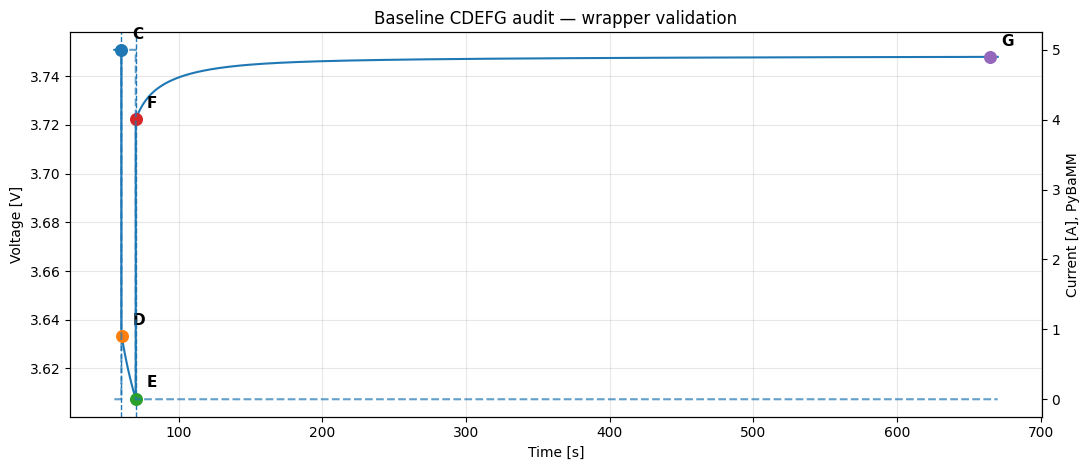

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/tier0_baseline_CDEFG_wrapper_validation.png


In [8]:
plot_mask = (
    (baseline_df["time_rel_s"] >= baseline_result["pulse_start_s"] - 5)
    & (baseline_df["time_rel_s"] <= baseline_result["pulse_end_s"] + RELAXATION_S)
)

fig, ax1 = plt.subplots(figsize=(11, 4.8))

ax1.plot(
    baseline_df.loc[plot_mask, "time_rel_s"],
    baseline_df.loc[plot_mask, "voltage_V"],
    label="Terminal voltage [V]",
)

for label, p in baseline_points.items():
    ax1.scatter(p["t_s"], p["U_V"], s=70, zorder=5)
    ax1.annotate(
        label,
        (p["t_s"], p["U_V"]),
        textcoords="offset points",
        xytext=(8, 8),
        fontsize=11,
        fontweight="bold",
    )

ax1.axvline(baseline_result["pulse_start_s"], linestyle="--", linewidth=1)
ax1.axvline(baseline_result["pulse_end_s"], linestyle="--", linewidth=1)

ax1.set_xlabel("Time [s]")
ax1.set_ylabel("Voltage [V]")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.step(
    baseline_df.loc[plot_mask, "time_rel_s"],
    baseline_df.loc[plot_mask, "current_A_pybamm"],
    where="post",
    linestyle="--",
    alpha=0.7,
)
ax2.set_ylabel("Current [A], PyBaMM")

plt.title("Baseline CDEFG audit — wrapper validation")

fig.tight_layout()
fig_path = FIGURES / "tier0_baseline_CDEFG_wrapper_validation.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)

In [9]:
base_param = pybamm.ParameterValues("Chen2020")

keywords = [
    "diffusivity",
    "exchange-current",
    "exchange current",
    "contact resistance",
]

for kw in keywords:
    print(f"\n--- keyword: {kw} ---")
    matches = [k for k in base_param.keys() if kw.lower() in k.lower()]
    for k in matches:
        print(k)


--- keyword: diffusivity ---
SEI solvent diffusivity [m2.s-1]
SEI lithium interstitial diffusivity [m2.s-1]
EC diffusivity [m2.s-1]
Negative particle diffusivity [m2.s-1]
Positive particle diffusivity [m2.s-1]
Electrolyte diffusivity [m2.s-1]

--- keyword: exchange-current ---
Negative electrode exchange-current density [A.m-2]
Positive electrode exchange-current density [A.m-2]

--- keyword: exchange current ---
SEI reaction exchange current density [A.m-2]

--- keyword: contact resistance ---
Contact resistance [Ohm]


In [10]:
def scaled_parameter_values(case_name, updates):
    """
    Build a Chen2020 parameter set with specified multiplicative/additive updates.

    updates format:
    {
        "parameter name": ("mul", factor)
        "parameter name": ("set", value)
    }
    """
    p = pybamm.ParameterValues("Chen2020")

    audit_rows = []

    for key, (mode, value) in updates.items():
        old_value = p[key]

        if mode == "mul":
            if callable(old_value):
                new_value = lambda *args, old_value=old_value, value=value: value * old_value(*args)
                update_note = f"callable multiplied by {value}"
            else:
                new_value = old_value * value
                update_note = f"{old_value} -> {new_value}"
        elif mode == "set":
            new_value = value
            update_note = f"{old_value} -> {new_value}"
        else:
            raise ValueError(f"Unknown mode: {mode}")

        p.update({key: new_value})

        audit_rows.append(
            {
                "case": case_name,
                "parameter": key,
                "mode": mode,
                "value": value,
                "old_type": type(old_value).__name__,
                "note": update_note,
            }
        )

    return p, pd.DataFrame(audit_rows)


tier0_case_specs = {
    "baseline": {},
    "Ds_n_x0p5": {
        "Negative particle diffusivity [m2.s-1]": ("mul", 0.5),
    },
    "Ds_p_x0p5": {
        "Positive particle diffusivity [m2.s-1]": ("mul", 0.5),
    },
    "j0_n_x0p5": {
        "Negative electrode exchange-current density [A.m-2]": ("mul", 0.5),
    },
    "j0_p_x0p5": {
        "Positive electrode exchange-current density [A.m-2]": ("mul", 0.5),
    },
    "contact_R_5mOhm": {
        "Contact resistance [Ohm]": ("set", 0.005),
    },
}

audit_tables = []
param_cases = {}

for case_name, updates in tier0_case_specs.items():
    if case_name == "baseline":
        param_cases[case_name] = pybamm.ParameterValues("Chen2020")
    else:
        p, audit = scaled_parameter_values(case_name, updates)
        param_cases[case_name] = p
        audit_tables.append(audit)

param_audit = pd.concat(audit_tables, ignore_index=True)
display(param_audit)

,case,parameter,mode,value,old_type,note
0,Ds_n_x0p5,Negative particle diffusivity [m2.s-1],mul,0.500,float,3.3e-14 -> 1.65e-14
1,Ds_p_x0p5,Positive particle diffusivity [m2.s-1],mul,0.500,float,4e-15 -> 2e-15
2,j0_n_x0p5,Negative electrode exchange-current density [A...,mul,0.500,function,callable multiplied by 0.5
3,j0_p_x0p5,Positive electrode exchange-current density [A...,mul,0.500,function,callable multiplied by 0.5
4,contact_R_5mOhm,Contact resistance [Ohm],set,0.005,int,0 -> 0.005


In [11]:
tier0_results = []
tier0_dfs = {}
tier0_points = {}
tier0_relax = {}
tier0_fit60 = {}
tier0_fit300 = {}

for case_name, p in param_cases.items():
    print(f"\n=== Running case: {case_name} ===")

    try:
        case_df, _ = run_hppc_case(
            case_name=case_name,
            parameter_values=p,
            soc_init=SOC_INIT,
        )

        result, points, relax, fit60, fit300 = extract_observables(case_df)
        result["case"] = case_name
        result["status"] = "ok"

        tier0_results.append(result)
        tier0_dfs[case_name] = case_df
        tier0_points[case_name] = points
        tier0_relax[case_name] = relax
        tier0_fit60[case_name] = fit60
        tier0_fit300[case_name] = fit300

        print("[OK]", case_name)
        print(f"Ri_CD = {result['Ri_CD_mohm']:.3f} mΩ")
        print(f"tau2_60s = {result['biexp60_tau2_s']:.3f} s")
        print(f"tau2_300s = {result['biexp300_tau2_s']:.3f} s")

    except Exception as e:
        print("[FAILED]", case_name, repr(e))
        tier0_results.append(
            {
                "case": case_name,
                "status": "failed",
                "error": repr(e),
            }
        )

tier0_table = pd.DataFrame(tier0_results)

out_csv = DATA / "tier0_mechanism_sanity_scan_soc50.csv"
tier0_table.to_csv(out_csv, index=False)

print("\n[OK] saved:", out_csv)
display(tier0_table)


=== Running case: baseline ===
[OK] baseline
Ri_CD = 23.545 mΩ
tau2_60s = 48.698 s
tau2_300s = 107.086 s

=== Running case: Ds_n_x0p5 ===
[OK] Ds_n_x0p5
Ri_CD = 23.546 mΩ
tau2_60s = 48.706 s
tau2_300s = 107.028 s

=== Running case: Ds_p_x0p5 ===
[OK] Ds_p_x0p5
Ri_CD = 23.546 mΩ
tau2_60s = 61.622 s
tau2_300s = 134.162 s

=== Running case: j0_n_x0p5 ===
[OK] j0_n_x0p5
Ri_CD = 30.306 mΩ
tau2_60s = 48.751 s
tau2_300s = 106.586 s

=== Running case: j0_p_x0p5 ===
[OK] j0_p_x0p5
Ri_CD = 25.953 mΩ
tau2_60s = 48.753 s
tau2_300s = 107.441 s

=== Running case: contact_R_5mOhm ===
[OK] contact_R_5mOhm
Ri_CD = 23.545 mΩ
tau2_60s = 48.698 s
tau2_300s = 107.086 s

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/tier0_mechanism_sanity_scan_soc50.csv


,pulse_start_s,pulse_end_s,pulse_duration_s,Ri_CD_mohm,Ri_EF_mohm,C_U_V,D_U_V,E_U_V,F_U_V,G_U_V,...,biexp60_residual_max_abs_mV,biexp60_n_fit_points,biexp300_tau1_s,biexp300_tau2_s,biexp300_R2,biexp300_RMSE_mV,biexp300_residual_max_abs_mV,biexp300_n_fit_points,case,status
0,60.0,70.0,10.0,23.545486,22.969868,3.750874,3.633146,3.607630,3.722479,3.747969,...,0.177654,596,18.331299,107.085635,0.998717,0.150494,1.224541,2996,baseline,ok
1,60.0,70.0,10.0,23.545555,22.974905,3.750874,3.633146,3.607566,3.722441,3.747969,...,0.177332,596,18.310771,107.028405,0.998714,0.150877,1.227135,2996,Ds_n_x0p5,ok
2,60.0,70.0,10.0,23.546335,22.947501,3.750874,3.633142,3.604937,3.719675,3.747413,...,0.133572,596,23.435222,134.162100,0.999662,0.092631,0.718631,2996,Ds_p_x0p5,ok
3,60.0,70.0,10.0,30.306247,29.684101,3.750874,3.599342,3.574016,3.722436,3.747969,...,0.175192,596,18.397573,106.585968,0.998713,0.151347,1.227138,2996,j0_n_x0p5,ok
4,60.0,70.0,10.0,25.953266,25.499213,3.750874,3.621107,3.595032,3.722528,3.747969,...,0.175583,596,18.411112,107.440626,0.998742,0.148951,1.209996,2996,j0_p_x0p5,ok
5,60.0,70.0,10.0,23.545486,22.969868,3.750874,3.633146,3.607630,3.722479,3.747969,...,0.177654,596,18.331299,107.085635,0.998717,0.150494,1.224541,2996,contact_R_5mOhm,ok


In [12]:
ok_table = tier0_table[tier0_table["status"] == "ok"].copy()

baseline_row = ok_table[ok_table["case"] == "baseline"].iloc[0]

metrics = [
    "Ri_CD_mohm",
    "Ri_EF_mohm",
    "biexp60_tau1_s",
    "biexp60_tau2_s",
    "biexp300_tau1_s",
    "biexp300_tau2_s",
    "G_U_V",
]

drift_rows = []

for _, row in ok_table.iterrows():
    case = row["case"]
    out = {"case": case}

    for m in metrics:
        base_val = baseline_row[m]
        val = row[m]
        out[m] = val
        out[f"{m}_delta"] = val - base_val
        out[f"{m}_rel_pct"] = 100 * (val - base_val) / base_val if base_val != 0 else np.nan

    drift_rows.append(out)

drift_table = pd.DataFrame(drift_rows)

out_csv = DATA / "tier0_mechanism_sanity_scan_soc50_drift_table.csv"
drift_table.to_csv(out_csv, index=False)

print("[OK] saved:", out_csv)
display(drift_table)

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/data/tier0_mechanism_sanity_scan_soc50_drift_table.csv


,case,Ri_CD_mohm,Ri_CD_mohm_delta,Ri_CD_mohm_rel_pct,Ri_EF_mohm,Ri_EF_mohm_delta,Ri_EF_mohm_rel_pct,biexp60_tau1_s,biexp60_tau1_s_delta,biexp60_tau1_s_rel_pct,...,biexp60_tau2_s_rel_pct,biexp300_tau1_s,biexp300_tau1_s_delta,biexp300_tau1_s_rel_pct,biexp300_tau2_s,biexp300_tau2_s_delta,biexp300_tau2_s_rel_pct,G_U_V,G_U_V_delta,G_U_V_rel_pct
0,baseline,23.545486,0.000000,0.000000,22.969868,0.000000,0.000000,9.440863,0.000000,0.000000,...,0.000000,18.331299,0.000000,0.000000,107.085635,0.000000,0.000000,3.747969,0.000000e+00,0.000000
1,Ds_n_x0p5,23.545555,0.000069,0.000292,22.974905,0.005037,0.021927,9.429607,-0.011256,-0.119231,...,0.014835,18.310771,-0.020528,-0.111984,107.028405,-0.057230,-0.053443,3.747969,-6.458941e-08,-0.000002
2,Ds_p_x0p5,23.546335,0.000849,0.003607,22.947501,-0.022367,-0.097374,14.511739,5.070876,53.711996,...,26.538392,23.435222,5.103923,27.842669,134.162100,27.076465,25.284871,3.747413,-5.562591e-04,-0.014842
3,j0_n_x0p5,30.306247,6.760761,28.713619,29.684101,6.714233,29.230610,9.429586,-0.011278,-0.119457,...,0.108401,18.397573,0.066274,0.361536,106.585968,-0.499668,-0.466606,3.747969,2.204377e-07,0.000006
4,j0_p_x0p5,25.953266,2.407780,10.226079,25.499213,2.529345,11.011577,9.512988,0.072124,0.763959,...,0.111545,18.411112,0.079813,0.435390,107.440626,0.354990,0.331501,3.747969,-4.177436e-08,-0.000001
5,contact_R_5mOhm,23.545486,0.000000,0.000000,22.969868,0.000000,0.000000,9.440863,0.000000,0.000000,...,0.000000,18.331299,0.000000,0.000000,107.085635,0.000000,0.000000,3.747969,0.000000e+00,0.000000


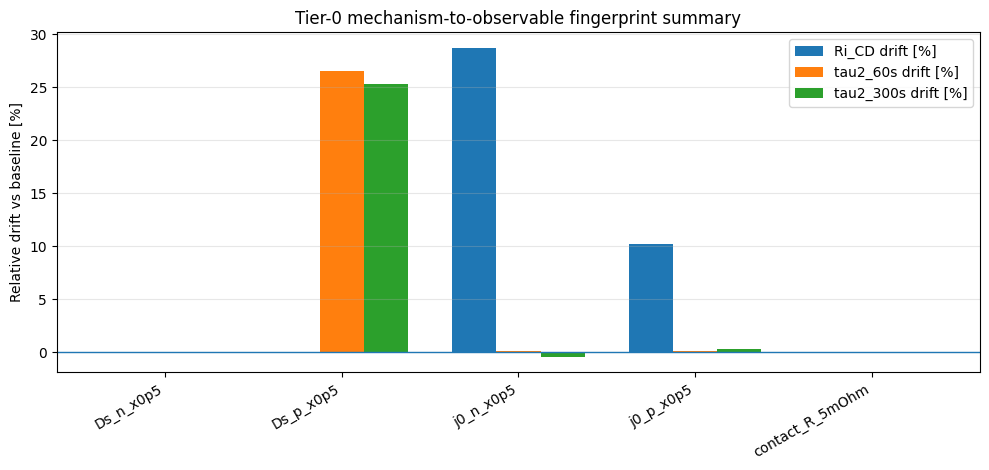

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/tier0_mechanism_fingerprint_summary.png


In [13]:
plot_df = drift_table[drift_table["case"] != "baseline"].copy()

fig, ax = plt.subplots(figsize=(10, 4.8))

x = np.arange(len(plot_df))
width = 0.25

ax.bar(x - width, plot_df["Ri_CD_mohm_rel_pct"], width, label="Ri_CD drift [%]")
ax.bar(x, plot_df["biexp60_tau2_s_rel_pct"], width, label="tau2_60s drift [%]")
ax.bar(x + width, plot_df["biexp300_tau2_s_rel_pct"], width, label="tau2_300s drift [%]")

ax.axhline(0, linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["case"], rotation=30, ha="right")
ax.set_ylabel("Relative drift vs baseline [%]")
ax.set_title("Tier-0 mechanism-to-observable fingerprint summary")
ax.grid(True, axis="y", alpha=0.3)
ax.legend()

fig.tight_layout()
fig_path = FIGURES / "tier0_mechanism_fingerprint_summary.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)

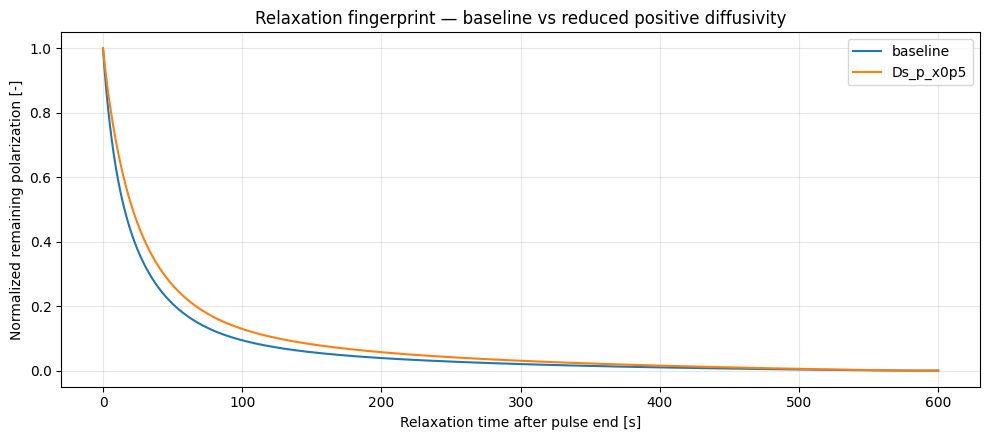

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/tier0_relaxation_overlay_baseline_vs_Ds_p_x0p5.png


In [14]:
case_a = "baseline"
case_b = "Ds_p_x0p5"

relax_a = tier0_relax[case_a]
relax_b = tier0_relax[case_b]

def normalized_remaining(relax):
    U0 = relax["voltage_V"].iloc[0]
    Uinf = np.median(relax.loc[relax["t_relax_s"] >= 550, "voltage_V"])
    y = (Uinf - relax["voltage_V"]) / (Uinf - U0)
    return np.clip(y, 1e-8, None)

y_a = normalized_remaining(relax_a)
y_b = normalized_remaining(relax_b)

fig, ax = plt.subplots(figsize=(10, 4.5))

ax.plot(relax_a["t_relax_s"], y_a, label=case_a)
ax.plot(relax_b["t_relax_s"], y_b, label=case_b)

ax.set_xlabel("Relaxation time after pulse end [s]")
ax.set_ylabel("Normalized remaining polarization [-]")
ax.set_title("Relaxation fingerprint — baseline vs reduced positive diffusivity")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
fig_path = FIGURES / "tier0_relaxation_overlay_baseline_vs_Ds_p_x0p5.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)

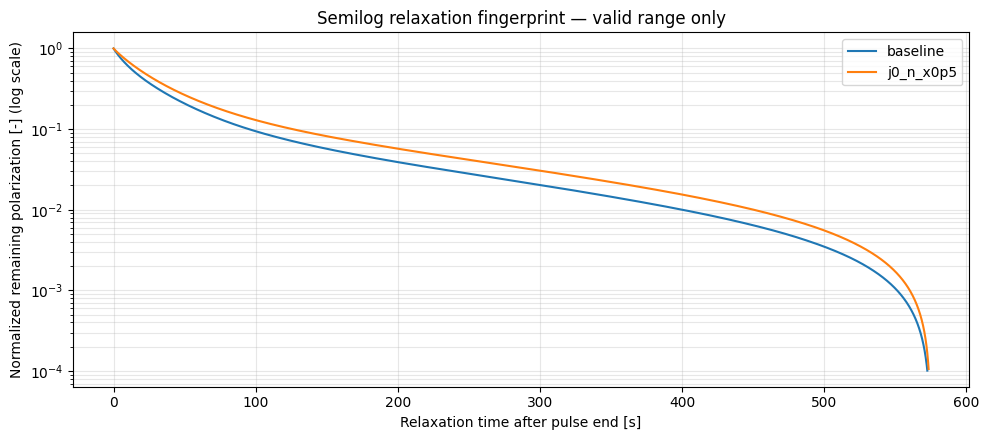

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/tier0_semilog_relaxation_overlay_baseline_vs_Ds_p_x0p5_valid_range.png


In [18]:
valid_a = y_a > 1e-4
valid_b = y_b > 1e-4

fig, ax = plt.subplots(figsize=(10, 4.5))

ax.semilogy(relax_a.loc[valid_a, "t_relax_s"], y_a[valid_a], label=case_a)
ax.semilogy(relax_b.loc[valid_b, "t_relax_s"], y_b[valid_b], label=case_b)

ax.set_xlabel("Relaxation time after pulse end [s]")
ax.set_ylabel("Normalized remaining polarization [-] (log scale)")
ax.set_title("Semilog relaxation fingerprint — valid range only")
ax.grid(True, which="both", alpha=0.3)
ax.legend()

fig.tight_layout()
fig_path = FIGURES / "tier0_semilog_relaxation_overlay_baseline_vs_Ds_p_x0p5_valid_range.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)

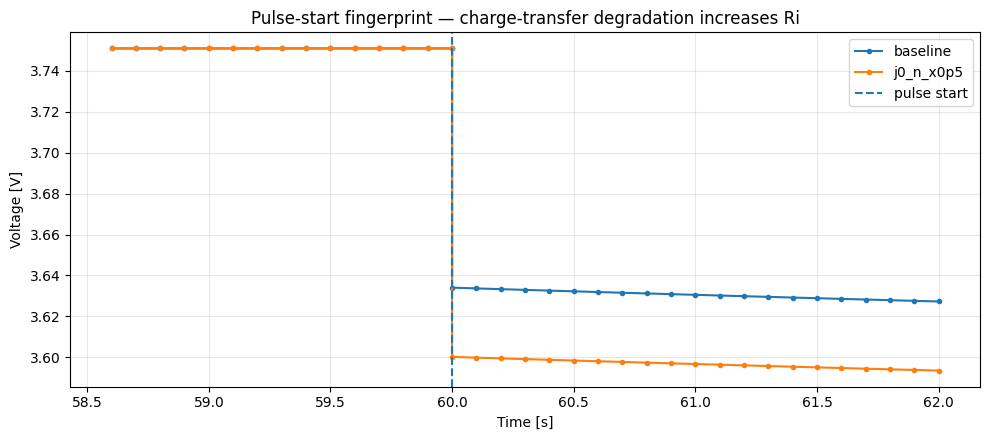

[OK] saved: /Users/louislu/projects/pybamm-aging-bridge/figures/tier0_pulse_start_overlay_baseline_vs_j0_n_x0p5.png


In [16]:
case_a = "baseline"
case_b = "j0_n_x0p5"

df_a = tier0_dfs[case_a]
df_b = tier0_dfs[case_b]

t0 = tier0_table.loc[tier0_table["case"] == "baseline", "pulse_start_s"].iloc[0]

zoom_mask_a = (df_a["time_rel_s"] >= t0 - 1.5) & (df_a["time_rel_s"] <= t0 + 2.0)
zoom_mask_b = (df_b["time_rel_s"] >= t0 - 1.5) & (df_b["time_rel_s"] <= t0 + 2.0)

fig, ax1 = plt.subplots(figsize=(10, 4.5))

ax1.plot(
    df_a.loc[zoom_mask_a, "time_rel_s"],
    df_a.loc[zoom_mask_a, "voltage_V"],
    marker="o",
    markersize=3,
    label=case_a,
)

ax1.plot(
    df_b.loc[zoom_mask_b, "time_rel_s"],
    df_b.loc[zoom_mask_b, "voltage_V"],
    marker="o",
    markersize=3,
    label=case_b,
)

ax1.axvline(t0, linestyle="--", label="pulse start")

ax1.set_xlabel("Time [s]")
ax1.set_ylabel("Voltage [V]")
ax1.set_title("Pulse-start fingerprint — charge-transfer degradation increases Ri")
ax1.grid(True, alpha=0.3)
ax1.legend()

fig.tight_layout()
fig_path = FIGURES / "tier0_pulse_start_overlay_baseline_vs_j0_n_x0p5.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("[OK] saved:", fig_path)